In [ ]:
import matplotlib
import pickle
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sb
from scipy import stats
from scipy.stats import binom
import datetime
import statistics
import multiprocess as mp
import time
import arviz as az
from sklearn.metrics import mean_squared_error

from epydemix import EpiModel
from epydemix import load_predefined_model
from epydemix.visualization import plot_quantiles, plot_trajectories, plot_posterior_distribution_2d
from epydemix.population import load_epydemix_population, Population, get_available_locations
from epydemix.visualization import plot_contact_matrix, plot_population
from epydemix.utils import compute_simulation_dates
from epydemix import simulate
from epydemix.calibration import ABCSampler, rmse
import matplotlib.pyplot as plt
import pandas as pd
from epydemix.visualization import plot_posterior_distribution

from Epy_functions import stochastic_sir
from Epy_functions import stochastic_sir_noisy
from Epy_functions import summary
from Epy_functions import weighted_ess

# Simulation

In [4]:
# Simulate an epidemic where the observations (incidence data) is only partially observed and overdispersed
model_noisy = stochastic_sir_noisy(0.3, 0.1, 10000, 10, 100, 0.25, 2)

In [5]:
# Isolate the observations
observed_noisy = model_noisy['noisy']

# Create DataFrame of observations (this is what Epydemix accepts)
noisy_df = pd.DataFrame(observed_noisy)
noisy_df = noisy_df.rename(columns={0: 'data'})
noisy_df['date'] = pd.date_range(start = '2024/01/01', periods = len(noisy_df), freq='D')


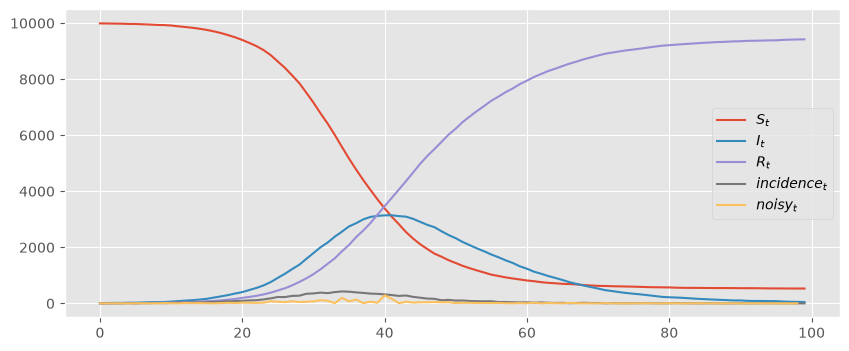

In [6]:
# Plot Epidemic evolution
plt.style.use('ggplot')
plt.figure(figsize=(10,4))
plt.plot(model_noisy['S'], label=r'$S_t$')
plt.plot(model_noisy['I'], label=r'$I_t$')
plt.plot(model_noisy['R'], label=r'$R_t$')
plt.plot(model_noisy['incidence'], label=r'$incidence_t$')
plt.plot(model_noisy['noisy'], label=r'$noisy_t$')
plt.legend()

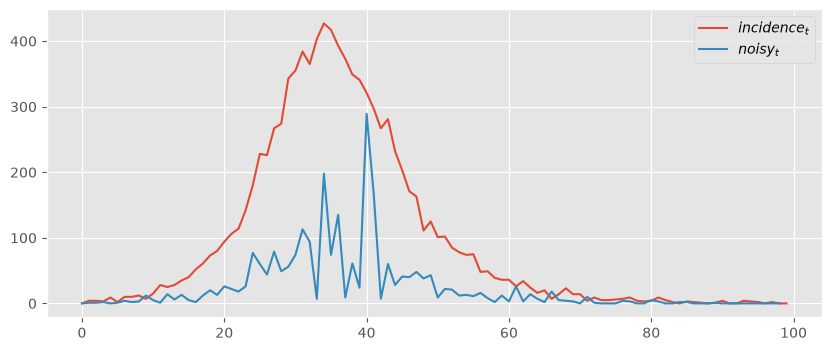

In [7]:
# Plot of true incidences vs observed incidences
plt.style.use('ggplot')
plt.figure(figsize=(10,4))
plt.plot(model_noisy['incidence'], label=r'$incidence_t$')
plt.plot(model_noisy['noisy'], label=r'$noisy_t$')
plt.legend()

# ABC-SMC Calibration

In [8]:
# Priors
priors = {"beta": stats.uniform(0, .5), 
          "gamma": stats.uniform(0.0, 0.5)}

# Simulation parameters
parameters_noisy = {'N': 10000,
                    'n_i': 10,
                    'timesteps': 100,
                    'rho': 0.25,
                    'phi': 2}

# Wrapper function
def simulate_wrapper_noisy(parameters_noisy):
    results = stochastic_sir_noisy(**parameters_noisy)
    return{'data': results['noisy']}

# Initialize the ABCSampler object
abc_sampler_noisy = ABCSampler(simulation_function=simulate_wrapper_noisy,
                         priors = priors,
                         parameters=parameters_noisy,
                         observed_data=observed_noisy,
                         distance_function = rmse)

In [9]:
def smc_calibrate(seed):
    np.random.seed(seed)
    results_smc = abc_sampler_noisy.calibrate(strategy='smc',
                                    num_particles=500,
                                    num_generations=10,
                                    )
    return results_smc

In [10]:
start = time.time()
with mp.Pool() as pool:
    pool_smc = pool.map(smc_calibrate, [1,2,3,4])
end = time.time()
print(f"Time taken: {end - start:.2f} seconds")

Starting ABC-SMC with 500 particles and 10 generationsStarting ABC-SMC with 500 particles and 10 generationsStarting ABC-SMC with 500 particles and 10 generationsStarting ABC-SMC with 500 particles and 10 generations




Generation 1/10 (epsilon: inf)
Generation 1/10 (epsilon: inf)
Generation 1/10 (epsilon: inf)
Generation 1/10 (epsilon: inf)



	Accepted 500/500 (acceptance rate: 100.00%)	Accepted 500/500 (acceptance rate: 100.00%)	Accepted 500/500 (acceptance rate: 100.00%)


	Elapsed time: 00:00:00	Elapsed time: 00:00:00	Elapsed time: 00:00:00



Generation 2/10 (epsilon: 50.177413)
Generation 2/10 (epsilon: 50.177664)
Generation 2/10 (epsilon: 50.178419)

	Accepted 500/500 (acceptance rate: 100.00%)

	Elapsed time: 00:00:00

Generation 2/10 (epsilon: 50.178268)
	Accepted 500/1368 (acceptance rate: 36.55%)
	Elapsed time: 00:00:00

Generation 3/10 (epsilon: 49.113145)
	Accepted 500/1382 (acceptance rate: 36.18%)
	Elapsed time: 00:00:00

Generation 3/10 (epsilon: 49.332922)
	Accepted 

In [11]:
# Extract posterior distributions (DataFrame of Beta and Gamma)
df_posterior_0 = pool_smc[0].get_posterior_distribution()
df_posterior_1 = pool_smc[1].get_posterior_distribution()
df_posterior_2 = pool_smc[2].get_posterior_distribution()
df_posterior_3 = pool_smc[3].get_posterior_distribution()

# Extract a NumPy array of beta posterior
post_0_beta = (df_posterior_0['beta']).to_numpy()
post_1_beta = (df_posterior_1['beta']).to_numpy()
post_2_beta = (df_posterior_2['beta']).to_numpy()
post_3_beta = (df_posterior_3['beta']).to_numpy()

# Extract a NumPy array of gamma posterior
post_0_gamma = (df_posterior_0['gamma']).to_numpy()
post_1_gamma = (df_posterior_1['gamma']).to_numpy()
post_2_gamma = (df_posterior_2['gamma']).to_numpy()
post_3_gamma = (df_posterior_3['gamma']).to_numpy()

# Create 2D array of posteriors
post_beta = np.array([post_0_beta, post_1_beta, post_2_beta, post_3_beta])
post_gamma = np.array([post_0_gamma, post_1_gamma, post_2_gamma, post_3_gamma])

# Results & Statistics

In [12]:
summary = summary('Beta', 'Gamma', post_beta, post_gamma, 4)

,Parameter,Mean,Variance,Std,eti95_lb,eti95_ub,hdi95_lb,hdi95_ub,ess_bulk,ess_tail,rhat,mcse_mean,mcse_std
0,Beta,0.3495,0.0052,0.0718,0.2338,0.4675,0.2452,0.4780,2175.4181,1934.0462,0.9997,0.0015,0.0008
1,Gamma,0.1784,0.0081,0.0902,0.0334,0.3262,0.0133,0.3032,2253.3385,1861.9036,0.9994,0.0019,0.0011


# Weighted ESS

ESS calculated according to the equations [here](https://codingace.net/maths/effective_sample_size.html). 

In [14]:
print(dir(pool_smc[0]))

['__annotations__', '__class__', '__dataclass_fields__', '__dataclass_params__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__match_args__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_compute_quantiles', '_get_generation', 'calibration_params', 'calibration_strategy', 'distances', 'get_calibration_quantiles', 'get_calibration_trajectories', 'get_distances', 'get_posterior_distribution', 'get_projection_quantiles', 'get_projection_trajectories', 'get_selected_trajectories', 'get_weights', 'observed_data', 'posterior_distributions', 'priors', 'projection_parameters', 'projections', 'selected_trajectories', 'weights']


In [16]:
ess_0_1 = weighted_ess(1, 4, pool_smc)
print(f"The ESS for chain 0, generation 1 is: {ess_0_1:.2f}")

The ESS for chain 0, generation 1 is: 461.91


In [17]:
for j in range(4):
    print(f'Chain {j}')
    for i in range(10):
        ess = weighted_ess(j, i, pool_smc)
        print(f"The ESS for chain {j}, generation {i} is: {ess:.2f}")

Chain 0
The ESS for chain 0, generation 0 is: 500.00
The ESS for chain 0, generation 1 is: 484.69
The ESS for chain 0, generation 2 is: 483.02
The ESS for chain 0, generation 3 is: 475.56
The ESS for chain 0, generation 4 is: 475.14
The ESS for chain 0, generation 5 is: 459.27
The ESS for chain 0, generation 6 is: 477.22
The ESS for chain 0, generation 7 is: 468.07
The ESS for chain 0, generation 8 is: 467.29
The ESS for chain 0, generation 9 is: 471.33
Chain 1
The ESS for chain 1, generation 0 is: 500.00
The ESS for chain 1, generation 1 is: 484.67
The ESS for chain 1, generation 2 is: 484.71
The ESS for chain 1, generation 3 is: 474.79
The ESS for chain 1, generation 4 is: 461.91
The ESS for chain 1, generation 5 is: 478.82
The ESS for chain 1, generation 6 is: 464.17
The ESS for chain 1, generation 7 is: 475.35
The ESS for chain 1, generation 8 is: 468.81
The ESS for chain 1, generation 9 is: 470.97
Chain 2
The ESS for chain 2, generation 0 is: 500.00
The ESS for chain 2, generation

# Bias & Error

In [33]:
# Calculate mean of posterior distributions of each chain (BETA)
chain0_beta_mean = np.mean(post_0_beta)
chain1_beta_mean = np.mean(post_1_beta)
chain2_beta_mean = np.mean(post_2_beta)
chain3_beta_mean = np.mean(post_3_beta)

# Calculate bias of posterior mean estimates of each chain (BETA)
beta_true = 0.3
chain0_beta_bias = chain0_beta_mean - beta_true
chain1_beta_bias = chain1_beta_mean - beta_true
chain2_beta_bias = chain2_beta_mean - beta_true
chain3_beta_bias = chain3_beta_mean - beta_true

# Calculate MSE of posterior mean estimates of each chain (BETA)
chain0_beta_mse = np.square(np.subtract(beta_true, chain0_beta_mean)).mean()
chain1_beta_mse = np.square(np.subtract(beta_true, chain1_beta_mean)).mean()
chain2_beta_mse = np.square(np.subtract(beta_true, chain2_beta_mean)).mean()
chain3_beta_mse = np.square(np.subtract(beta_true, chain3_beta_mean)).mean()

# Calculate mean of posterior distributions of each chain (GAMMA)
chain0_gamma_mean = np.mean(post_0_gamma)
chain1_gamma_mean = np.mean(post_1_gamma)
chain2_gamma_mean = np.mean(post_2_gamma)
chain3_gamma_mean = np.mean(post_3_gamma)

# Calculate bias of posterior mean estimates of each chain (GAMMA)
gamma_true = 0.1
chain0_gamma_bias = chain0_gamma_mean - gamma_true
chain1_gamma_bias = chain1_gamma_mean - gamma_true
chain2_gamma_bias = chain2_gamma_mean - gamma_true
chain3_gamma_bias = chain3_gamma_mean - gamma_true

# Calculate MSE of posterior mean estimates of each chain (GAMMA)
chain0_gamma_mse = np.square(np.subtract(gamma_true, chain0_gamma_mean)).mean()
chain1_gamma_mse = np.square(np.subtract(gamma_true, chain1_gamma_mean)).mean()
chain2_gamma_mse = np.square(np.subtract(gamma_true, chain2_gamma_mean)).mean()
chain3_gamma_mse = np.square(np.subtract(gamma_true, chain3_gamma_mean)).mean()


In [34]:
# DataFrame of parameter posterior mean estimates and resulting biases
df_beta = {'Beta Chains': ['Chain 0', 'Chain 1', 'Chain 2', 'Chain 3'],
           'Mean': [chain0_beta_mean, chain1_beta_mean, chain2_beta_mean, chain3_beta_mean],
           'Bias': [chain0_beta_bias, chain1_beta_bias, chain2_beta_bias, chain3_beta_bias],
           'MSE': [chain0_beta_mse, chain1_beta_mse, chain2_beta_mse, chain3_beta_mse]}

df_beta = pd.DataFrame(df_beta)

display(df_beta)

df_gamma = {'Gamma Chains': ['Chain 0', 'Chain 1', 'Chain 2', 'Chain 3'],
           'Mean': [chain0_gamma_mean, chain1_gamma_mean, chain2_gamma_mean, chain3_gamma_mean],
           'Bias': [chain0_gamma_bias, chain1_gamma_bias, chain2_gamma_bias, chain3_gamma_bias],
           'MSE': [chain0_gamma_mse, chain1_gamma_mse, chain2_gamma_mse, chain3_gamma_mse]}

df_gamma = pd.DataFrame(df_gamma)

display(df_gamma)

,Beta Chains,Mean,Bias,MSE
0,Chain 0,0.349438,0.049438,0.002444
1,Chain 1,0.347964,0.047964,0.002301
2,Chain 2,0.348913,0.048913,0.002392
3,Chain 3,0.351698,0.051698,0.002673


,Gamma Chains,Mean,Bias,MSE
0,Chain 0,0.179091,0.079091,0.006255
1,Chain 1,0.176341,0.076341,0.005828
2,Chain 2,0.176982,0.076982,0.005926
3,Chain 3,0.181081,0.081081,0.006574


# Plots

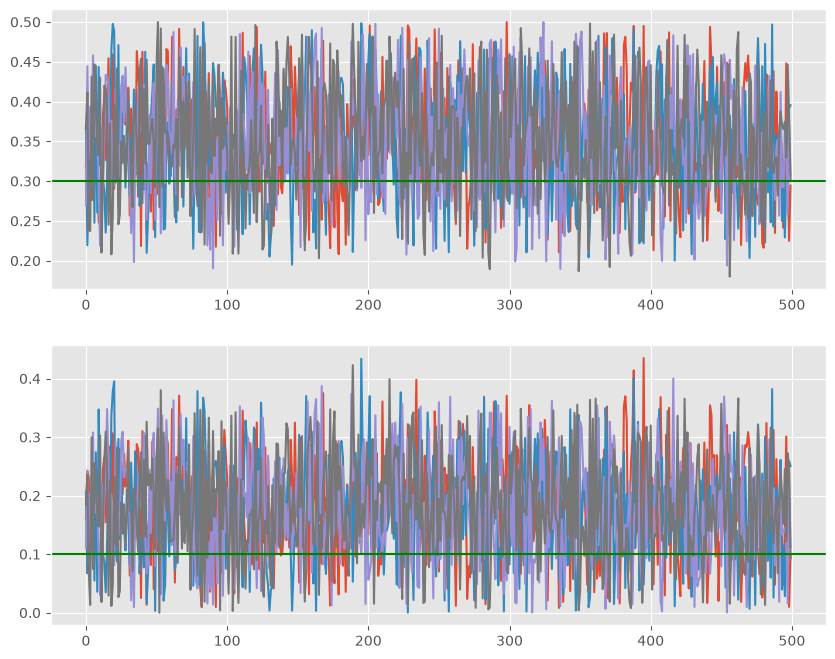

In [13]:
fig, axes = plt.subplots(2,1)
axes[0].plot(post_0_beta)
axes[0].plot(post_1_beta)
axes[0].plot(post_2_beta)
axes[0].plot(post_3_beta)
axes[1].plot(post_0_gamma)
axes[1].plot(post_1_gamma)
axes[1].plot(post_2_gamma)
axes[1].plot(post_3_gamma)
fig.set_figheight(8)
fig.set_figwidth(10)
axes[0].axhline(y = 0.3, color='green')
axes[1].axhline(y = 0.1, color='green')